<a href="https://colab.research.google.com/github/Prasanna-Mahajan-2006/Deepfake-Detector/blob/main/DSP_CNN_Term_Paper_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -q kagglehub

In [1]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
!pip install kagglehub -q

import kagglehub

print("Downloading dataset via kagglehub...")
# This will download the dataset and save the exact folder location to the 'path' variable
path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")

print(f"Success! Dataset downloaded to: {path}")

Using Colab cache for faster access to the 'deepfake-and-real-images' dataset.
Success! Dataset downloaded to: /kaggle/input/deepfake-and-real-images


In [9]:
# 1. Pull credentials securely from Colab Secrets
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# 2. Download and Unzip
print("Downloading dataset from Kaggle...")
!kaggle datasets download -d manjilkarki/deepfake-and-real-images

print("Unzipping dataset...")
!unzip -q deepfake-and-real-images.zip -d original_dataset
print("Unzip complete!")

NameError: name 'userdata' is not defined

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Peek inside the downloaded directory to confirm the folder name (usually 'Dataset')
print("Contents of the downloaded path:", os.listdir(path))



In [2]:
# Extracting the datasets into variables
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{path}/Dataset/Train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{path}/Dataset/Validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{path}/Dataset/Test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

NameError: name 'path' is not defined

In [ ]:
data_augmentation = tf.keras.Sequential([
    # Variances are standard deviations squared (0.229^2, 0.224^2, 0.225^2)
    # these are the actual mean intensities of red, blue and green from the ImageNet dataset.
    # Needed for normalization to run the gradient descent
    layers.Normalization(mean=[0.485, 0.456, 0.406], variance=[0.0524, 0.0501, 0.0506]),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=10./360.),
    layers.RandomBrightness(factor=0.2), # Simulating color jittering
    layers.RandomContrast(factor=0.2)    # Simulating color jittering
])

# --- MODEL ARCHITECTURE ---
# Note: Using MobileNetV3Small as a placeholder since V4 is not native to Keras yet.
# By fine-tuning the model to detect subtle artifacts unique to deepfakes and employing optimization techniques, this work aims to deliver an effective yet scalable detection framework.
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True

# The extracted features are refined through dimensionality reduction before being passed to a dense layer.
# To enhance generalization and minimize overfitting, techniques like dropout or normalization are applied before the dense layer.
# Finally, a binary classifier with a sigmoid activation function ensures accurate classification of the input.
model = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# --- TRAINING ---
# The optimizer employed back-propagation and the Adam algorithm.
# The model was trained using a cross-entropy loss function.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# The MobileNetV4-Small model was trained over 11 epochs.
# Abhi: I set epochs = 3 for quicker results.
#       Also I added the steps_per_epoch to skip over some images, as the dataset is large.
history = model.fit(
    train_ds,
    steps_per_epoch = 20, # means that it trains only 20 batches per epoch.
    validation_data=val_ds,
    epochs=10
)

# --- EVALUATION ---
# During testing, the model's accuracy on the test data was calculated similarly to the training phase.
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

In [ ]:
# 1. Configuration
BATCH_SIZE = 64
IMG_SIZE = (224, 224)
EPOCHS = 50
# Updated to point to your newly extracted 100k dataset
DATASET_DIR = '/content/my_100k_dataset'

# 2. Data Loading
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Optimize data loading for GPU
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

# 3. Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 4. Base Model (Native Keras MobileNetV3 Small)
base_model = keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze base layers

# 5. Build the Final Model
inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)

# Pass through the base model (MobileNetV3 handles its own pixel scaling internally!)
x = base_model(x)

# Convert 3D feature maps to 1D feature vectors
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)

# 6. Compilation
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# 7. Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("best_deepfake_model.keras", save_best_only=True, monitor='val_accuracy'),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
]

# 8. Training
print(f"Starting training for {EPOCHS} epochs...")
history = model.fit(
    train_dataset,
    epochs=EPOCH,
    validation_data=val_dataset,
    callbacks=callbacks
)

print("Training complete! Model saved as 'best_deepfake_model.keras'")

In [ ]:
source_dir = '/content/original_dataset'
dest_dir = '/content/my_100k_dataset'

# Create the clean destination directories
os.makedirs(os.path.join(dest_dir, 'Real'), exist_ok=True)
os.makedirs(os.path.join(dest_dir, 'Fake'), exist_ok=True)

all_real = []
all_fake = []

# 1. Scan the original dataset and map all file paths
print("Scanning original dataset...")
for root, dirs, files in os.walk(source_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, file)
            # The folder structure dictates the class
            if 'real' in root.lower():
                all_real.append(full_path)
            elif 'fake' in root.lower():
                all_fake.append(full_path)

print(f"Found {len(all_real)} total Real images and {len(all_fake)} total Fake images.")

# 2. Randomly sample 50,000 from each (with a safety net)
target_size = 50000
real_sample_size = min(target_size, len(all_real))
fake_sample_size = min(target_size, len(all_fake))

real_sample = random.sample(all_real, real_sample_size)
fake_sample = random.sample(all_fake, fake_sample_size)

# 3. Copy the sampled images to your new clean directory
print(f"Copying {real_sample_size} Real images to new directory...")
for i, img_path in enumerate(real_sample):
    shutil.copy(img_path, os.path.join(dest_dir, 'Real', f"real_{i}.jpg"))

print(f"Copying {fake_sample_size} Fake images to new directory...")
for i, img_path in enumerate(fake_sample):
    shutil.copy(img_path, os.path.join(dest_dir, 'Fake', f"fake_{i}.jpg"))

print("Done! Your 100,000 image dataset is beautifully prepped.")

In [11]:
# Prasanna - changing the above code as Kaggle has updated its library so we no longer need the API keys

# 1. Define Variables (To prevent NameErrors)
IMG_SIZE = (224, 224)
BATCH_SIZE = 64

# 2. Download the dataset effortlessly (No API keys or Unzipping needed!)
print("Downloading dataset via kagglehub...")
path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")
print(f"Dataset securely downloaded to: {path}\n")

# 3. Load the datasets into Keras
print("Loading Training Data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{path}/Dataset/Train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Validation Data...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{path}/Dataset/Validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nLoading Testing Data...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{path}/Dataset/Test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nSuccess! All datasets are loaded and ready for training.")

Using Colab cache for faster access to the 'deepfake-and-real-images' dataset.
Dataset securely downloaded to: /kaggle/input/deepfake-and-real-images

Loading Training Data...
Found 140002 files belonging to 2 classes.

Loading Validation Data...
Found 39428 files belonging to 2 classes.

Loading Testing Data...
Found 10905 files belonging to 2 classes.

Success! All datasets are loaded and ready for training.


Building the model architecture...
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Starting training... (Make sure your GPU is on!)
Epoch 1/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 624s 280ms/step - accuracy: 0.7032 - loss: 0.5825 - precision: 0.6997 - recall: 0.7117 - val_accuracy: 0.7171 - val_loss: 0.5474 - val_precision: 0.8635 - val_recall: 0.5181
Epoch 2/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 248s 113ms/step - accuracy: 0.7185 - loss: 0.5566 - precision: 0.7146 - recall: 0.7276 - val_accuracy: 0.7059 - val_loss: 0.5571 - val_precision: 0.8538 - val_recall: 0.4995
Epoch 3/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 249s 114ms/step - accuracy: 0.7174 - loss: 0.5560 - precision: 0.7133 - recall: 0.7269 - val_accuracy: 0.6899 - val_loss: 0.5756 - val_precision: 0.8584 - val_recall: 0.4576
Epoch 4/30
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 216s 99ms/step - accuracy: 0.7196 - loss: 0.5541 - precision: 0.7149 - recall: 0.7303 - val_accuracy: 0.7059 - val_loss: 0.5605 - val_precision: 0.8506 - val_recall: 0.5022
Epo

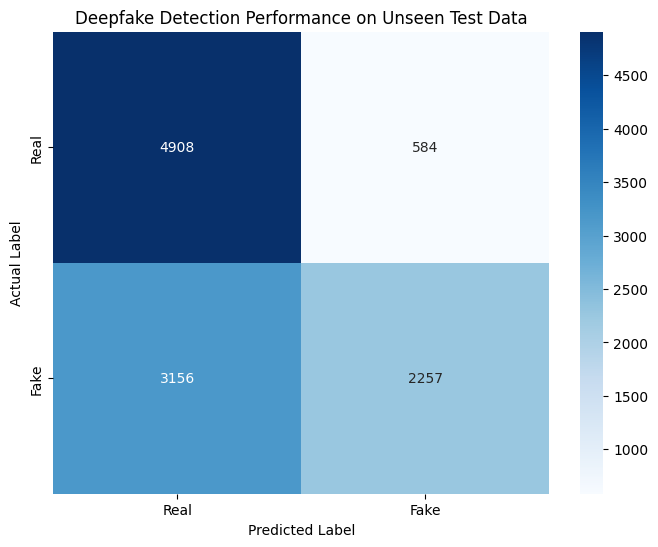

In [12]:
IMG_SIZE = (224, 224)
EPOCHS = 30

# 2. MODEL ARCHITECTURE (High Regularization)
print("Building the model architecture...")
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name="data_augmentation")

base_model = keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze the base model to preserve ImageNet features

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)

# Regularization to prevent overfitting
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Final classification layer with L2 Regularization
outputs = layers.Dense(
    1, activation='sigmoid',
    kernel_regularizer=regularizers.l2(0.01)
)(x)

model = keras.Model(inputs, outputs)

# 3. COMPILATION
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    keras.callbacks.ModelCheckpoint("best_deepfake_model.keras", save_best_only=True, monitor='val_accuracy'),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
]

# 4. TRAINING
print("\nStarting training... (Make sure your GPU is on!)")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

# 5. POST-TRAINING METRICS & CONFUSION MATRIX
print("\n--- Generating Final Evaluation Metrics on Test Set ---")

# Evaluate basic metrics on the unseen Test set
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# IMPORTANT: To generate a Confusion Matrix, we must load the test data WITHOUT shuffling
# Otherwise, our predictions won't line up with the true labels!
print("Re-loading test data for Confusion Matrix (shuffle=False)...")
test_ds_unshuffled = tf.keras.utils.image_dataset_from_directory(
    f"{path}/Dataset/Test",
    image_size=IMG_SIZE,
    batch_size=64,
    shuffle=False # <--- This is the magic key for a correct confusion matrix
)

# Extract true labels
y_true = np.concatenate([y for x, y in test_ds_unshuffled], axis=0)

# Generate predictions
print("Generating predictions...")
y_pred_probs = model.predict(test_ds_unshuffled)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Classification Report (Includes F1 Score)
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Real (0)', 'Fake (1)']))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Deepfake Detection Performance on Unseen Test Data')
plt.show()

Building the architecture...

--- PHASE 1: Warming up the classification head (5 Epochs) ---
Epoch 1/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 257s 115ms/step - accuracy: 0.7039 - loss: 0.5835 - val_accuracy: 0.7030 - val_loss: 0.5605
Epoch 2/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 223s 102ms/step - accuracy: 0.7179 - loss: 0.5565 - val_accuracy: 0.7192 - val_loss: 0.5436
Epoch 3/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 211s 97ms/step - accuracy: 0.7199 - loss: 0.5543 - val_accuracy: 0.6980 - val_loss: 0.5681
Epoch 4/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 209s 95ms/step - accuracy: 0.7186 - loss: 0.5548 - val_accuracy: 0.7128 - val_loss: 0.5503
Epoch 5/5
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 208s 95ms/step - accuracy: 0.7193 - loss: 0.5549 - val_accuracy: 0.6986 - val_loss: 0.5657

--- PHASE 2: Unfreezing MobileNet for Fine-Tuning ---
Total layers in base model: 157
Starting deep fine-tuning... (Aiming for 85%+)
Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 220s 97ms/step - accuracy: 0.7357 - loss: 0.5299 - precision: 0.7266 

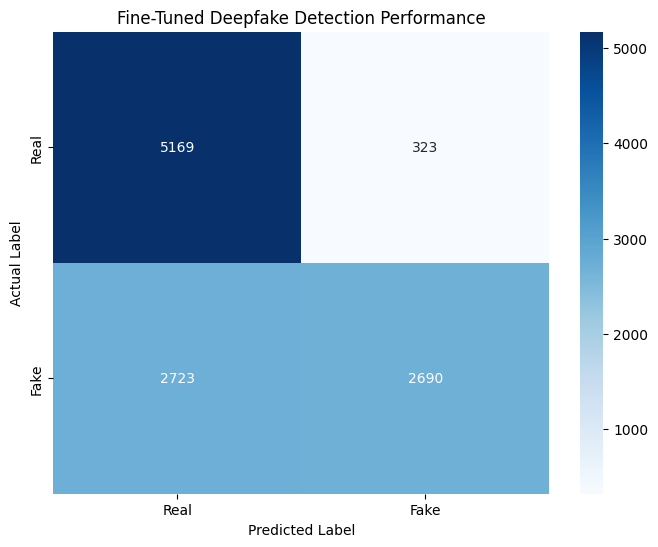

In [13]:
# Prasanna - Now trying with Transfer Learning methods - first train the frozen model for 5 epochs, then unfreeze some layers in phase 2 and check for improvements
# ==========================================
# 1. BUILD THE MODEL (PHASE 1 SETUP)
# ==========================================
print("Building the architecture...")
IMG_SIZE = (224, 224)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name="data_augmentation")

base_model = keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
# Freeze the base model for the warm-up phase
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01))(x)

model = keras.Model(inputs, outputs)

# Compile for Phase 1
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# ==========================================
# 2. PHASE 1: WARM-UP TRAINING
# ==========================================
print("\n--- PHASE 1: Warming up the classification head (5 Epochs) ---")
# We just want to stabilize the new dense layers quickly
history_warmup = model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds
)

# ==========================================
# 3. PHASE 2: FINE-TUNING THE BASE MODEL
# ==========================================
print("\n--- PHASE 2: Unfreezing MobileNet for Fine-Tuning ---")

# Unfreeze the base model
base_model.trainable = True

# MobileNetV3Small has about 229 layers. We will freeze the bottom 150 layers
# (which detect basic lines/colors) and unfreeze the top 79 layers
# (which detect complex shapes like facial artifacts).
print(f"Total layers in base model: {len(base_model.layers)}")
for layer in base_model.layers[:150]:
    layer.trainable = False

# CRUCIAL: Recompile the model with a severely reduced learning rate (1e-5 instead of 1e-3)
# We want tiny, gentle updates to the pre-trained weights.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# Setup Advanced Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint("best_finetuned_model.keras", save_best_only=True, monitor='val_accuracy'),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    # This automatically lowers the learning rate if validation loss plateaus for 2 epochs
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
]

print("Starting deep fine-tuning... (Aiming for 85%+)")
history_finetune = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks
)

# ==========================================
# 4. FINAL EVALUATION
# ==========================================
print("\n--- Generating Final Evaluation Metrics on Test Set ---")
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_ds)
print(f"\nFINAL Test Accuracy: {test_acc*100:.2f}%")

print("Re-loading test data for Confusion Matrix (shuffle=False)...")
# Note: Ensure 'path' variable is still in memory from your kagglehub download cell
test_ds_unshuffled = tf.keras.utils.image_dataset_from_directory(
    f"{path}/Dataset/Test",
    image_size=IMG_SIZE,
    batch_size=64,
    shuffle=False
)

y_true = np.concatenate([y for x, y in test_ds_unshuffled], axis=0)
y_pred_probs = model.predict(test_ds_unshuffled)
y_pred = (y_pred_probs > 0.5).astype("int32")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Real (0)', 'Fake (1)']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Fine-Tuned Deepfake Detection Performance')
plt.show()